In [1]:
from typing import Optional
import numpy as np
import gymnasium as gym
import math
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [66]:
class FMCGEnv(gym.Env):

    def __init__(self,
                 p_min: float,
                 p_max: float,
                 p_diff: float,
                 H: int,
                 alpha: np.ndarray = np.array([40.0, 20.0]),
                 beta: np.ndarray = np.array([3.0, 1.2]),
                 sens_attr_mapping: Optional[list] = None
                 ):
        """ Initialize FMCG Gymnasium environment.

        Args:
            p_min (float): minimum price
            p_max (float): maximum price
            p_diff (float): price step
            H (int): length of episode
            alpha (np.array): demand core state param. (market size)
            beta (np.array): demand core state param. (price elasticity)
            sens_attr_mapping (list, optional): mapping of time steps to sensitive attributes
        """
        # main parameters
        self.p_min = p_min
        self.p_max = p_max
        self.p_diff = p_diff
        self.H = H
        self.alpha = alpha
        self.beta = beta

        # set sensitive attribute mapping
        if sens_attr_mapping is not None:
            if not (len(sens_attr_mapping) == self.H):
                raise ValueError(
                    "Sensitive attribute mapping with respect to t should be of length H."
                )
            else:
                self._t_to_sens_attr = sens_attr_mapping
        else:
            # initialize randomly a sensitive attribute
            self._t_to_sens_attr = np.random.randint(0, 2, size=self.H)

        # check user input
        if not self._is_p_consistent(self.p_min, self.p_max, self.p_diff):
            raise ValueError(
                "Inconsistent price parameters, (p_max - p_min) / p_diff is not an integer."
            )

        # Initialize state
        # Using -1 as "uninitialized" state
        self._demand = -1.0
        self._t = -1
        self._sensitive_attr = -1

        # Define what the agent can observe
        # 3 times the maximum demand (lowest price) is set as max. demand
        max_d0 = 3 * (self.alpha[0] - self.beta[0] * self.p_min)
        max_d1 = 3 * (self.alpha[1] - self.beta[1] * self.p_min)
        self._max_d = max(max_d0, max_d1)
        self.observation_space = gym.spaces.Dict({
            "demand": gym.spaces.Box(
                low=0.0,
                high=self._max_d,
                shape=(1,),
                dtype=np.float32
            ),
            "t": gym.spaces.Discrete(self.H),
            "sensitive_attr": gym.spaces.Discrete(2)
        })
        
        # The available actions correspond to possible price points
        num_actions = round((self.p_max - self.p_min) / self.p_diff) + 1
        self.action_space = gym.spaces.Discrete(num_actions)

        # Map action numbers to actual price points
        # rounding guards against floating point inconsistencies
        self._action_to_price = {
            i: round(self.p_min + i * self.p_diff, 10)
            for i in range(num_actions)
        }
    
    def reset(self,
                seed: Optional[int] = None,
                options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration

        Returns:
            tuple: (observation, info) for the initial state
        """
        # IMPORTANT: Must call this first to seed the random number generator
        super().reset(seed=seed)

        # At the start of the episode t = 0
        self._t = 0
        self._sensitive_attr = self._t_to_sens_attr[self._t]  

        # At time point 0 the demand is for a random price
        init_price = self._action_to_price[self.np_random.integers(0, self.action_space.n)]
        self._demand = max(0.0, self.alpha[self._sensitive_attr] - self.beta[self._sensitive_attr] * init_price)

        observation = self._get_obs()
        info = self._get_info()
 
        return observation, info
    
    def step(self, action):
        """Execute one timestep within the environment.

        Args:
            action: The action to take

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        # Map the discrete action to a price
        p = self._action_to_price[action]

        # Observe demand based on core state and noise
        e_t = self.np_random.integers(-2, 3)
        self._demand = max(0.0, self.alpha[self._sensitive_attr] - self.beta[self._sensitive_attr] * p + e_t)

        # Check if episode ended 
        terminated = (self._t == (self.H - 1))

        # Update time step
        self._t += 1
        if not terminated:
            self._sensitive_attr = self._t_to_sens_attr[self._t]   

        # We don't use truncation in this environment
        truncated = False

        # Reward is the obtained revenue
        reward = p *  self._demand

        observation = self._get_obs()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            dict: Observation with demand and time point
        """
        # apply min-max scaling to demand
        demand_out = np.array([self._demand / self._max_d], dtype=np.float32)

        return {"demand":  demand_out,
                 "t": int(self._t),
                 "sensitive_attr": int(self._sensitive_attr)}

    def _get_info(self):
        """ Placeholder method for aiding debugging
        """
        return {}

    @staticmethod
    def _is_p_consistent(p_min:float,
                         p_max:float,
                         p_diff:float) -> bool:
        """ Checks consistency of price parameters.
        
        Args:
            p_min (float): minimum price
            p_max (float): maximum price
            p_diff (float): price step

        Returns:
            bool: indicates whether price params. are consistent
        """
        # to have an int. number of steps, the price range
        # should be divisible by p_diff
        n = (p_max - p_min) / p_diff
        return math.isclose(n, round(n), rel_tol=1e-9)

In [67]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=300,  # Prevent infinite episodes
)

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\envs\registration.py:637: UserWarning: WARN: Overriding environment gymnasium_env/FMCGEnv already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [68]:
env = gym.make("gymnasium_env/FMCGEnv",
               p_min=5.0, p_max=10.0, p_diff=0.1,
               H=52
               )

In [69]:
# test initialization
obs0, info0 = env.reset()
print(obs0)

# test an action
observation, reward, terminated, truncated, info = env.step(5)
print(observation)

{'demand': array([0.28533334], dtype=float32), 't': 0, 'sensitive_attr': 0}
{'demand': array([0.32666665], dtype=float32), 't': 1, 'sensitive_attr': 0}


In [70]:
# define alg running in T epsidoes of MDP
def random_alg(env1,H,T):
    """ Policy choosing randomly for T episodes of length H.
    """

    env = copy.deepcopy(env1)
    rew = np.zeros(T)
    action_hist = np.zeros((H,T))
    groups = np.zeros((H,T))
    # reg = np.zeros(T)

    for t in range(T):
        # sample initial state
        observation, info = env.reset()
        # optval =
        
        #record reward received over episode
        eprew = 0.0
        for h in range(H):
            # save the group wrt. sensitive attribute
            groups[h,t] = observation['sensitive_attr']
            
            # take action randomly and save it
            rng = np.random.default_rng()
            action = rng.integers(low=0, high=env.action_space.n)
            action_hist[h,t] = action

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(action)
            eprew += reward

        # reg[t] = optval -eprew 
        rew[t] = eprew
        
    return rew, action_hist, groups

In [71]:
rewards, action_hist, groups = random_alg(env, 52, 100)

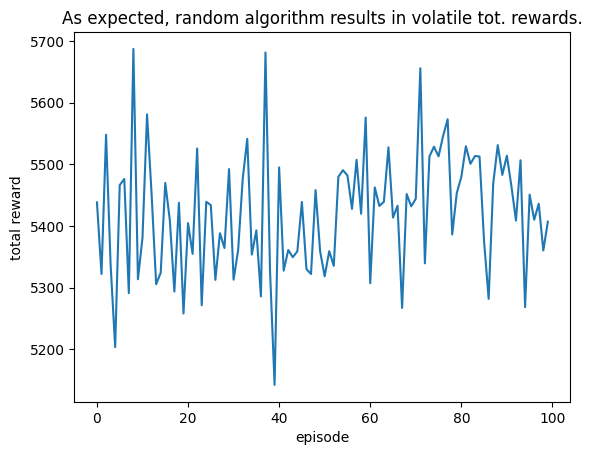

In [72]:
sns.lineplot(rewards)
plt.xlabel("episode")
plt.ylabel("total reward")
plt.title("As expected, random algorithm results in volatile tot. rewards.")
plt.show()

In [73]:
def jains_index(means):
    """ Jain's index, based on Maestre et al. (2018)
    """

    # calculate the denominator and nominator
    nom = np.sum(means)**2
    denom = len(means) * np.sum(means**2)

    return nom / denom

In [74]:
# test on a trivial example
jains_index(np.array([100,4,3]))

np.float64(0.3806816292601829)

In [75]:
action_hist

array([[16., 48.,  0., ..., 24., 41.,  5.],
       [46., 23.,  6., ..., 39., 34., 30.],
       [49.,  9.,  2., ..., 13., 16., 38.],
       ...,
       [35., 26.,  9., ..., 38., 24.,  0.],
       [45., 49., 15., ..., 42., 19., 21.],
       [36., 38., 30., ...,  2., 12., 20.]])

In [76]:
groups

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [77]:
mean0 = np.mean(action_hist[groups == 0])
mean1 = np.mean(action_hist[groups == 1])

ji_random = jains_index(np.array([mean0,mean1]))

print(f"Jain's index for the random algorithm is: {ji_random:.4f}")

Jain's index for the random algorithm is: 1.0000


## Implementing Proximal Policy Optimization

In [78]:
from stable_baselines3.ppo import PPO

In [91]:
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=FMCGEnv(p_min=5.0,
                        p_max=10.0,
                        p_diff=0.1,
                        H=52),
            learning_rate=0.0001,
            batch_size=64, # default
            clip_range=0.2, # default
            )
model.learn(total_timesteps=25000)

In [92]:
def running_model(env1,
                  alg,
                  H,
                  T
                  ):
    """ Policy choosing for T episodes of length H.
    """

    env = copy.deepcopy(env1)
    rew = np.zeros((H,T))
    action_hist = np.zeros((H,T))
    groups = np.zeros((H,T))
    # reg = np.zeros(T)

    for t in range(T):
        # sample initial state
        observation, info = env.reset()
        # optval =
        
        #record reward received over episode
        eprew = 0.0
        for h in range(H):
            # save the group wrt. sensitive attribute
            groups[h,t] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation)
            a = int(np.asarray(action).item())
            action_hist[h,t] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)
            eprew += reward

            # reg[t] = optval -eprew 
            rew[h,t] = reward
        
    return rew, action_hist, groups

In [93]:
rewards, action_hist, groups = running_model(env, model, 52, 1000)

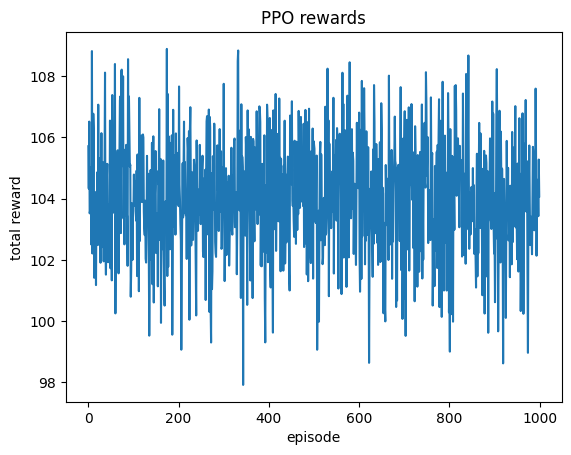

In [94]:
sns.lineplot(rewards.mean(axis=0))
plt.xlabel("episode")
plt.ylabel("total reward")
plt.title("PPO rewards")
plt.show()

In [95]:
mean0 = np.mean(action_hist[groups == 0])
mean1 = np.mean(action_hist[groups == 1])

ji_random = jains_index(np.array([mean0,mean1]))

print(f"Jain's index for PPO is: {ji_random:.4f}")

Jain's index for PPO is: 1.0000


Text(0, 0.5, 'reward')

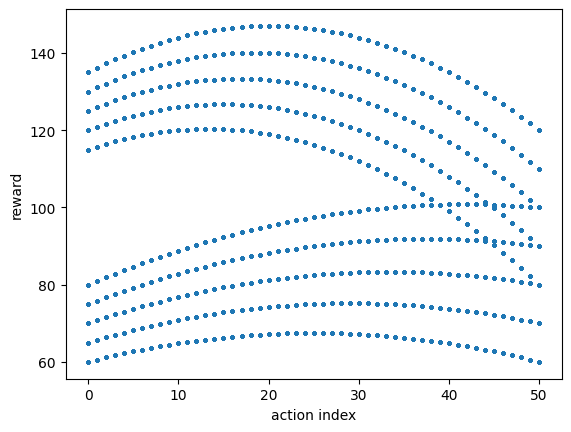

In [96]:
plt.scatter(action_hist.flatten(), rewards.flatten(), alpha=0.1, s=5)
plt.xlabel("action index")
plt.ylabel("reward")

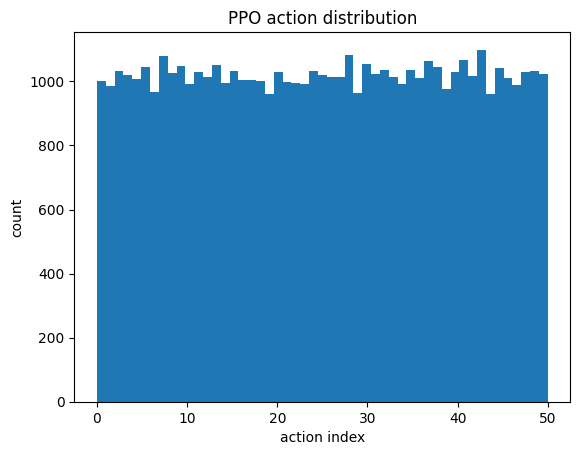

In [97]:
plt.hist(action_hist.flatten(), bins=51)
plt.xlabel("action index")
plt.ylabel("count")
plt.title("PPO action distribution")
plt.show()